# Script to read and alayze meep-simulation data  

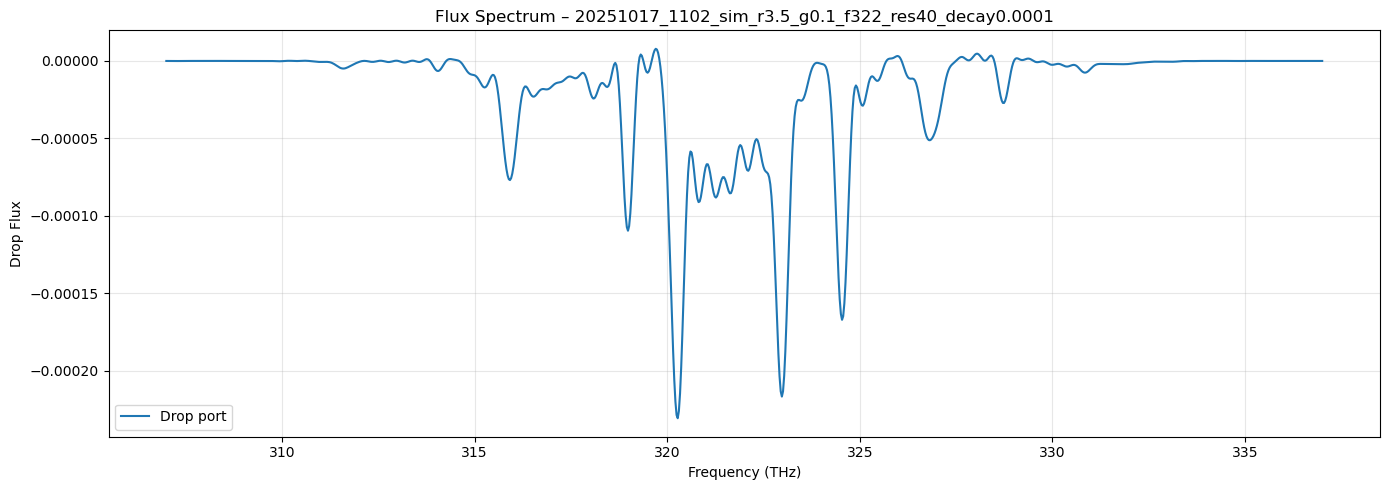


 Resonance frequencies for 20251017_1102_sim_r3.5_g0.1_f322_res40_decay0.0001:
[]


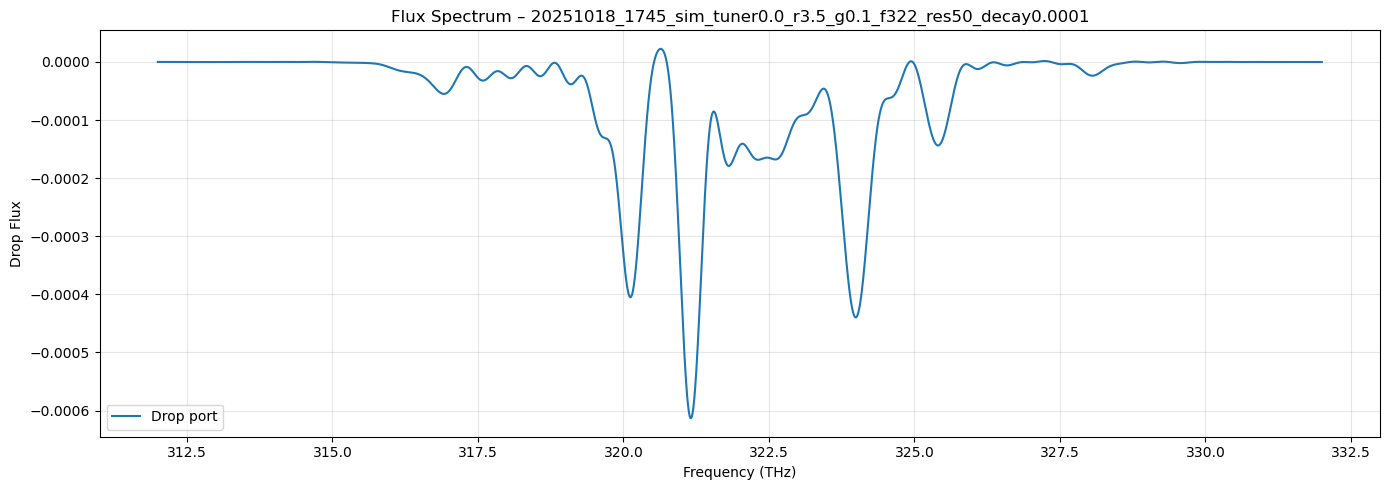


 Resonance frequencies for 20251018_1745_sim_tuner0.0_r3.5_g0.1_f322_res50_decay0.0001:
[]


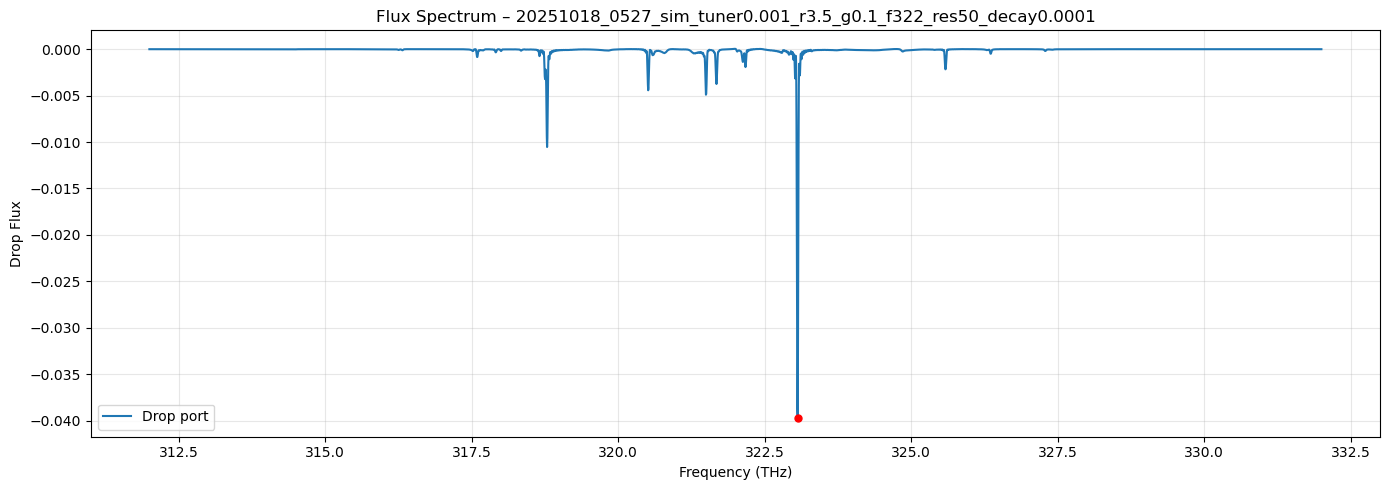


 Resonance frequencies for 20251018_0527_sim_tuner0.001_r3.5_g0.1_f322_res50_decay0.0001:
[323.0628]


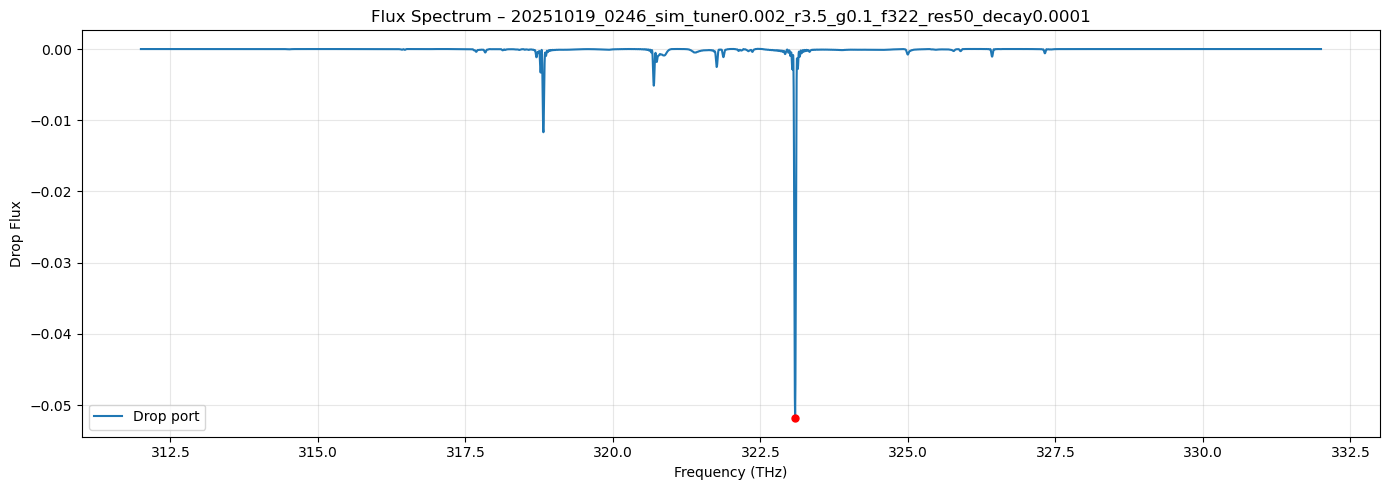


 Resonance frequencies for 20251019_0246_sim_tuner0.002_r3.5_g0.1_f322_res50_decay0.0001:
[323.0878]


In [20]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # speed of light in m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Base directory
# ---------------------------------
base_dir = "data"

# ---------------------------------
# Choose which simulation runs to plot
# ---------------------------------
selected_folders = [
    "20251017_1102_sim_r3.5_g0.1_f322_res40_decay0.0001",
    "20251018_1745_sim_tuner0.0_r3.5_g0.1_f322_res50_decay0.0001",
    "20251018_0527_sim_tuner0.001_r3.5_g0.1_f322_res50_decay0.0001",
    "20251019_0246_sim_tuner0.002_r3.5_g0.1_f322_res50_decay0.0001"
]

# ---------------------------------
# Helper: load flux data from HDF5
# ---------------------------------
def load_flux_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq = f["frequency"][:]       # Meep units (1/µm)
        flux_bus = f["flux_bus"][:]
        flux_drop = f["flux_drop"][:]
    return freq, flux_bus, flux_drop

# ---------------------------------
# Helper: parse parameters from folder name
# ---------------------------------
def parse_params_from_name(folder_name):
    pattern = (
        r"(?P<date>\d{8})_(?P<time>\d{4})_sim_r(?P<r>[\d\.]+)_g(?P<g>[\d\.]+)"
        r"_f(?P<f>[\d\.]+)_res(?P<res>\d+)_decay(?P<decay>[\deE\-\+\.]+)"
    )
    match = re.search(pattern, folder_name)
    return match.groupdict() if match else {}

# ---------------------------------
# Collect resonance data
# ---------------------------------
resonance_summary = []

# ---------------------------------
# Main loop: process and plot each dataset
# ---------------------------------
for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    flux_file = os.path.join(run_dir, "flux_data.h5")

    if not os.path.exists(flux_file):
        print(f"No flux_data.h5 found in {run_dir}, skipping.")
        continue

    # --- Load flux data ---
    freq_meep, flux_bus, flux_drop = load_flux_data(flux_file)

    # --- Convert Meep frequency to THz ---
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # --- Normalize drop-port flux ---
    #flux_drop = flux_drop / np.max(np.abs(flux_drop))

    # --- Find resonance peaks ---
    peaks, _ = find_peaks(-flux_drop, prominence=0.03)
    res_freqs = freq_thz[peaks]

    # --- Get parameters for labeling ---
    params = parse_params_from_name(folder)
    date = params.get("date", "unknown")
    time = params.get("time", "unknown")
    r = params.get("r", "?")
    g = params.get("g", "?")
    res = params.get("res", "?")

    # --- Save for summary plot ---
    resonance_summary.append({
        "folder": folder,
        "res_freqs": res_freqs,
        "date": date,
        "time": time
    })

    # --- Plot each dataset separately ---
    plt.figure(figsize=(14,5))
    plt.plot(freq_thz, flux_drop, lw=1.5, color="C0", label="Drop port")
    #plt.plot(freq_thz, flux_bus, lw=1.5, color="C1", label="Bus port")
    plt.scatter(res_freqs, flux_drop[peaks], color="red", s=25, zorder=5)

    # --- Labels and title ---
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Drop Flux")
    plt.title(f"Flux Spectrum – {folder}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # --- Show or save plot ---
    plt.show()

    # --- Print resonance info ---
    print(f"\n Resonance frequencies for {folder}:")
    print(np.round(res_freqs, 4))


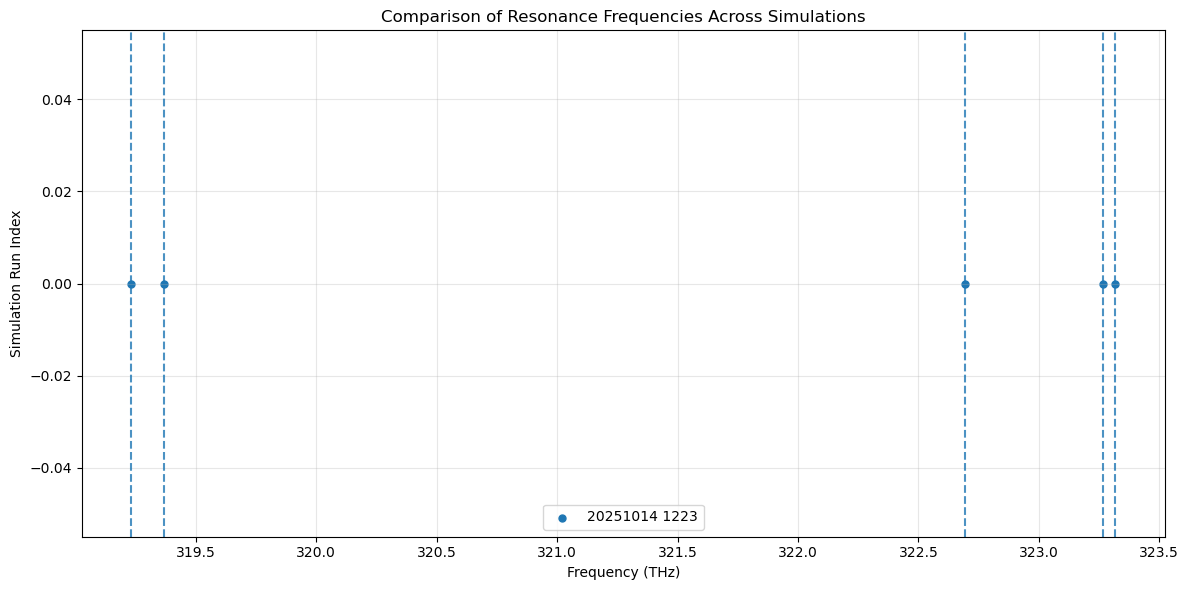

In [14]:
# ---------------------------------
# Summary: plot resonance frequencies of all runs
# ---------------------------------
plt.figure(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, entry in enumerate(resonance_summary):
    res_freqs = entry["res_freqs"]
    label = f"{entry['date']} {entry['time']}"
    for f in res_freqs:
        plt.axvline(f, color=colors[i % len(colors)], linestyle='--', alpha=0.8)
    plt.scatter(res_freqs, np.ones_like(res_freqs) * i, color=colors[i % len(colors)], s=25, label=label)

plt.xlabel("Frequency (THz)")
plt.ylabel("Simulation Run Index")
plt.title("Comparison of Resonance Frequencies Across Simulations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### with harminv

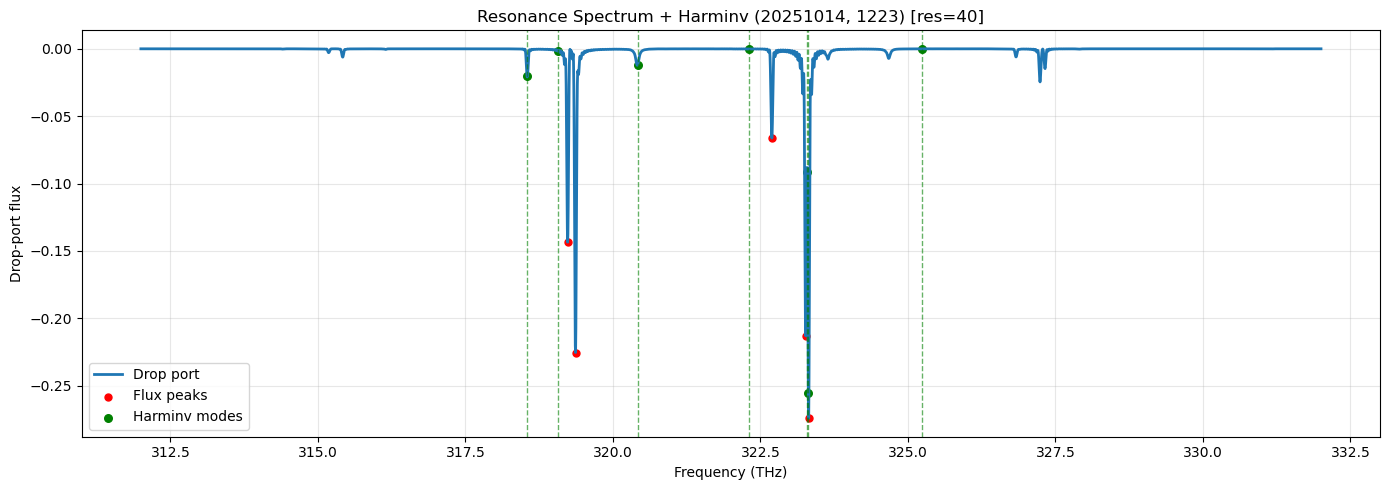


Resonances for 20251014_1223_sim_r3.5_g0.1_f322_res40_decay0.0001:
  Flux peaks (THz): [319.2318 319.3668 322.6927 323.2678 323.3178]
  Harminv modes (THz, Q):
    318.545 THz   Q = 34202.5
    319.068 THz   Q = 73210.7
    320.420 THz   Q = 5281.2
    322.310 THz   Q = 34235.5
    323.287 THz   Q = 21170.4
    323.311 THz   Q = 131262.1
    325.246 THz   Q = 33614.0


In [17]:

# ---------------------------------
# Helper: load flux data from HDF5
# ---------------------------------
def load_flux_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq = f["frequency"][:]       # Meep units (1/µm)
        flux_bus = f["flux_bus"][:]
        flux_drop = f["flux_drop"][:]
    return freq, flux_bus, flux_drop

# ---------------------------------
# Helper: load harminv data if available
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
    return freq_meep, Q, decay

# ---------------------------------
# Helper: parse parameters from folder name
# ---------------------------------
def parse_params_from_name(folder_name):
    pattern = (
        r"(?P<date>\d{8})_(?P<time>\d{4})_sim_r(?P<r>[\d\.]+)_g(?P<g>[\d\.]+)"
        r"_f(?P<f>[\d\.]+)_res(?P<res>\d+)_decay(?P<decay>[\deE\-\+\.]+)"
    )
    match = re.search(pattern, folder_name)
    return match.groupdict() if match else {}

# ---------------------------------
# Collect resonance data
# ---------------------------------
resonance_summary = []

# ---------------------------------
# Main loop: process and plot each dataset
# ---------------------------------
for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    flux_file = os.path.join(run_dir, "flux_data.h5")
    harminv_file = os.path.join(run_dir, "harminv_data.h5")

    if not os.path.exists(flux_file):
        print(f"No flux_data.h5 found in {run_dir}, skipping.")
        continue

    # --- Load flux data ---
    freq_meep, flux_bus, flux_drop = load_flux_data(flux_file)
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # --- Find resonance peaks ---
    peaks, _ = find_peaks(-flux_drop, prominence=0.03)
    res_freqs = freq_thz[peaks]

    # --- Try to load Harminv data ---
    harminv_thz = []
    harminv_Q = []
    if os.path.exists(harminv_file):
        freq_meep_h, Q, decay = load_harminv_data(harminv_file)
        harminv_thz = freq_meep_h * (c0 / um_scale) / 1e12
        harminv_Q = Q
    else:
        print(f"No harminv_data.h5 found in {run_dir}.")

    # --- Parse parameters ---
    params = parse_params_from_name(folder)
    date = params.get("date", "unknown")
    time = params.get("time", "unknown")
    res = params.get("res", "?")

    # --- Plot each dataset ---
    plt.figure(figsize=(14, 5))
    plt.plot(freq_thz, flux_drop, lw=2, color="C0", label="Drop port")
    plt.scatter(res_freqs, flux_drop[peaks], color="red", s=25, label="Flux peaks")

    # --- Add Harminv resonances ---
    if len(harminv_thz) > 0:
        for f, q in zip(harminv_thz, harminv_Q):
            plt.axvline(f, color="green", ls="--", lw=1, alpha=0.6)
        plt.scatter(harminv_thz, np.interp(harminv_thz, freq_thz, flux_drop),
                    color="green", s=30, label="Harminv modes")

    # --- Labels and title ---
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Drop-port flux")
    plt.title(f"Resonance Spectrum + Harminv ({date}, {time}) [res={res}]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Print info ---
    print(f"\nResonances for {folder}:")
    print("  Flux peaks (THz):", np.round(res_freqs, 4))
    if len(harminv_thz) > 0:
        print("  Harminv modes (THz, Q):")
        for f, q in zip(harminv_thz, harminv_Q):
            print(f"    {f:.3f} THz   Q = {q:.1f}")


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

def load_and_plot_flux_data(folder_name, base_dir="data", convert_to_thz=True):
    """
    Load and plot flux data from .npy files in the specified data subfolder.

    Parameters
    ----------
    folder_name : str
        Name of the subfolder inside 'data/' containing flux_bus.npy, flux_drop.npy, and freqs.npy
    base_dir : str, optional
        Base directory where data folders are stored (default: 'data')
    convert_to_thz : bool, optional
        Convert frequency axis from Meep units (1/µm) to THz (default: True)

    Returns
    -------
    freqs : np.ndarray
        Frequency array (THz if convert_to_thz=True)
    flux_bus : np.ndarray
        Flux data from the bus waveguide
    flux_drop : np.ndarray
        Flux data from the drop waveguide
    """
    # --- Paths ---
    folder_path = os.path.join(base_dir, folder_name)
    freq_file = os.path.join(folder_path, "freqs.npy")
    flux_bus_file = os.path.join(folder_path, "flux_bus.npy")
    flux_drop_file = os.path.join(folder_path, "flux_drop.npy")

    # --- Check existence ---
    for fpath in [freq_file, flux_bus_file, flux_drop_file]:
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing file: {fpath}")

    # --- Load data ---
    freqs = np.load(freq_file)
    flux_bus = np.load(flux_bus_file)
    flux_drop = np.load(flux_drop_file)

    # --- Convert to THz if requested ---
    if convert_to_thz:
        freqs = freqs * 299.792458  # Meep units (1/µm) → THz

    min_flux = np.min(flux_drop)
    min_freq = freqs[np.argmin(flux_drop)]
    print(f"Minimum flux at {min_freq:.4f} THz: {min_flux:.2e}")

    # --- Plot ---
    plt.figure(figsize=(15, 5))
    plt.plot(freqs, flux_drop, label="Drop port", lw=2)
    plt.xlabel("Frequency (THz)" if convert_to_thz else "Frequency (1/µm)")
    plt.ylabel("Flux")
    plt.title(f"Flux Spectrum – {folder_name}")
    plt.legend()
    plt.grid(True, ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return freqs, flux_bus, flux_drop


Minimum flux at 323.2913 THz: -2.21e-02


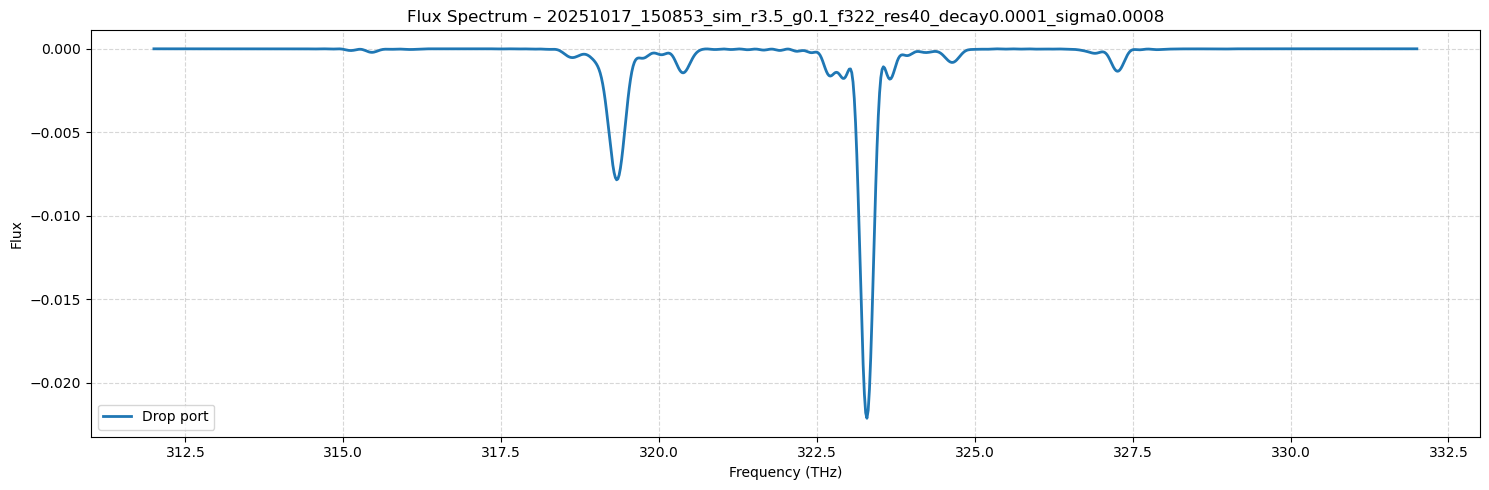

In [19]:
folder = "20251017_150853_sim_r3.5_g0.1_f322_res40_decay0.0001_sigma0.0008"
freqs, flux_bus, flux_drop = load_and_plot_flux_data(folder)

# optional: convert to THz if your Meep frequencies are in 1/µm
freqs_THz = freqs * 299.792458  # since 1/µm × c0 (µm/ps) = THz